Following this example notebook: https://github.com/planetlabs/notebooks/blob/master/jupyter-notebooks/use-cases/temporal-analysis/crop-temporal.ipynb

In [1]:
## Dependencies
# !pip install geojson planet rasterio shapely

In [29]:
# Can use this jupyter magic to automatically time each code block
# !pip install ipython-autotime
# %load_ext autotime
# %unload_ext autotime

In [3]:
import datetime
import json
import os
import requests
import shutil
import subprocess

import geojson
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from planet import Auth, reporting
from planet import Session, DataClient, OrdersClient
import rasterio
from shapely.geometry import shape

In [5]:
# Change directory to match the example structure
os.chdir('Projects/PaddockTS/Notebooks')

In [6]:
!ls

01_pre-segment.ipynb   paddock_segment_v1.ipynb
Ozwald.py	       paddock_ts_clust_plots_ta.ipynb
Ozwald_background.py   paddock_ts_clust_step2.ipynb
aminations_SILO.py     paddock_ts_clust_step2_ta.ipynb
calendar_plots.ipynb   paddock_ts_clust_step3_animation_.ipynb
climate_ANUClim.py     phenology_vids.ipynb
climate_SILO.py        planetscope_3_bands.ipynb
climate_comparison.py  planetscope_8_bands.ipynb
data		       planetscope_crop-temporal-Copy1.py
merge_3_bands.ipynb    planetscope_crop-temporal.ipynb
merge_4_bands.ipynb    src


In [7]:
ground_truth_file = os.path.join('src', 'ground-truth.geojson')

def load_geojson(filename):
    with open(filename, 'r') as f:
        return json.load(f)

ground_truth = load_geojson(ground_truth_file)

In [8]:
crop_ground_truth = [f for f in ground_truth
                     if f['properties']['CLASS1'] == 'F']
print('{} out of {} features are field crops.'
      .format(len(crop_ground_truth),len(ground_truth)))

991 out of 7429 features are field crops.


In [9]:
field_type_names = {
    1: 'cotton',
    2: 'safflower',
    3: 'flax',
    4: 'hops',
    5: 'sugar beets',
    6: 'corn',
    7: 'grain sorghum',
    8: 'sudan',
    9: 'castor beans',
    10: 'beans',
    11: 'misc field',
    12: 'sunflowers',
    13: 'hybrid sorghum/sudan',
    14: 'millet',
    15: 'sugar cane'
}

In [10]:
cat_crop_ground_truth = [f for f in crop_ground_truth
                         if f['properties']['SUBCLASS1'] != '**']
print('{} out of {} crop field features are categorized.'
      .format(len(cat_crop_ground_truth),len(crop_ground_truth)))

946 out of 991 crop field features are categorized.


In [11]:
# define and create test directory
# delete it if it already exists to ensure we start from a clear slate
test_dir = Path('data', 'test')
if os.path.isdir(test_dir):
    shutil.rmtree(test_dir)
test_dir.mkdir(parents=True)

In [12]:
field_geojson = cat_crop_ground_truth[0]


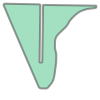

In [13]:
shape(field_geojson['geometry'])


In [14]:
def get_id(field_geojson):
    return field_geojson['id']

print(get_id(field_geojson))

87


In [15]:
def create_save_dir(aoi_geojson, root_dir='data'):
    save_dir = os.path.join(root_dir, get_id(aoi_geojson))

    if not os.path.isdir(save_dir):
        os.makedirs(save_dir)
    return save_dir

save_dir = create_save_dir(field_geojson)
print(save_dir)

data/87


In [16]:
def save_geojson_file(aoi_geojson, save_dir):
    filename = os.path.join(save_dir, 'aoi.geojson')
    with open(filename, "w") as f:
        f.write(json.dumps(aoi_geojson))
    return filename

geojson_filename = save_geojson_file(field_geojson, save_dir)
print('wrote to {}'.format(geojson_filename))

wrote to data/87/aoi.geojson


In [17]:
field_aoi = field_geojson['geometry']

In [22]:
os.environ['PL_API_KEY'] = 'PASTE_API_KEY_HERE'

In [23]:
API_KEY = os.environ.get('PL_API_KEY')
URL = "https://api.planet.com/data/v1"
session = requests.Session()
session.auth = (API_KEY, "")

In [20]:
# create an API Request from the search specifications

item_type = ['PSScene']

geom_filter = {
   "type":"GeometryFilter",
   "field_name":"geometry",
   "config":field_aoi
}

date_range_filter = {
"type":"DateRangeFilter",
"field_name":"acquired",
"config":{
  "gt":"2017-06-01T00:00:00Z", 
   "lt": "2017-10-01T00:00:00Z"}
}

combined_filter = {
"type":"AndFilter",
"config":[
    geom_filter,
    date_range_filter]
}

In [24]:
# Create the Request
# Also Get Some Stats About Our Request!
async with Session() as sess:
    cl = DataClient(sess)
    request = await cl.create_search(name='field_search',search_filter=combined_filter, item_types=item_type)
    stats = await cl.get_stats(search_filter=combined_filter, item_types=item_type, interval='month')

In [25]:
stats

{'buckets': [{'count': 24, 'start_time': '2017-06-01T00:00:00.000000Z'},
  {'count': 37, 'start_time': '2017-07-01T00:00:00.000000Z'},
  {'count': 33, 'start_time': '2017-08-01T00:00:00.000000Z'},
  {'count': 28, 'start_time': '2017-09-01T00:00:00.000000Z'}],
 'interval': 'month',
 'utc_offset': '+0h'}

In [26]:
# utilities for retrieving scene information and filtering to only scenes that totally overlap field
def get_items(client, request, limit=500):
    # run search
    # if you don't have an API key configured, this will raise an exception
    result = client.quick_search(request)
    return result.items_iter(limit=limit)

def filter_by_overlaps(items, aoi):
    aoi_shape = shape(aoi)
    
    def get_overlap(item):
        item_shape = shape(item['geometry'])
        overlap = 100.0*(aoi_shape.intersection(item_shape).area / aoi_shape.area)
        return overlap
    return (i for i in items if get_overlap(i) > 99)


async with Session() as sess:
    cl = DataClient(sess)
    items = cl.run_search(search_id=request['id'])
    item_list = [i async for i in items]
    filtered_items = filter_by_overlaps(item_list, field_aoi)
    filtered_list = [i for i in filtered_items]  


print(filtered_list[0]['id'])
print(filtered_list[0]['properties'])

20170729_181143_0e2f
{'acquired': '2017-07-29T18:11:43.92672Z', 'anomalous_pixels': 0.01, 'cloud_cover': 0.02, 'ground_control': True, 'gsd': 4, 'instrument': 'PS2', 'item_type': 'PSScene', 'pixel_resolution': 3, 'provider': 'planetscope', 'published': '2021-02-17T23:23:22Z', 'publishing_stage': 'finalized', 'quality_category': 'standard', 'satellite_azimuth': 105.2, 'satellite_id': '0e2f', 'strip_id': '654652', 'sun_azimuth': 118.5, 'sun_elevation': 57.4, 'updated': '2021-02-17T23:23:22Z', 'view_angle': 1.7}


In [27]:
# We can see all of the image IDs matching our search request
for i in filtered_list:
    print (i['id'])

20170729_181143_0e2f
20170926_190204_0f2e
20170924_180919_100c
20170923_180901_0f31
20170923_181342_0e0f
20170922_181038_1004
20170920_180941_102a
20170919_181118_1008
20170919_181016_1032
20170909_180818_101b
20170909_180907_0f43
20170908_180801_1038
20170908_190242_0f36
20170908_190411_0f44
20170908_181110_1034
20170905_180956_0f42
20170905_190413_0f40
20170903_180654_100a
20170901_180914_1010
20170901_180914_1008
20170831_190411_101c
20170831_190418_1043
20170830_190308_0f53
20170829_180853_103e
20170828_180806_101f
20170828_180626_0f35
20170826_180921_0f34
20170825_180652_1012
20170823_180827_0f18
20170822_181346_0e1f
20170822_180912_103d
20170821_180923_102e
20170820_180643_1039
20170819_180637_1029
20170818_190642_1053
20170818_190629_1050
20170818_180751_1022
20170816_180907_1011
20170814_180733_100c
20170813_180853_0f31
20170808_180849_0f43
20170807_180725_1027
20170807_180737_1038
20170803_234859_1_0c54
20170802_180622_100a
20170731_180522_0f1b
20170730_180739_0f17
20170728_18

In [28]:
item = filtered_list[0]
item


{'_links': {'_self': 'https://api.planet.com/data/v1/item-types/PSScene/items/20170729_181143_0e2f',
  'assets': 'https://api.planet.com/data/v1/item-types/PSScene/items/20170729_181143_0e2f/assets/',
  'thumbnail': 'https://tiles.planet.com/data/v1/item-types/PSScene/items/20170729_181143_0e2f/thumb'},
 '_permissions': ['assets.basic_analytic_4b:download',
  'assets.basic_analytic_4b_rpc:download',
  'assets.basic_analytic_4b_xml:download',
  'assets.basic_udm2:download',
  'assets.ortho_analytic_3b:download',
  'assets.ortho_analytic_3b_xml:download',
  'assets.ortho_analytic_4b:download',
  'assets.ortho_analytic_4b_sr:download',
  'assets.ortho_analytic_4b_xml:download',
  'assets.ortho_udm2:download',
  'assets.ortho_visual:download'],
 'assets': ['basic_analytic_4b',
  'basic_analytic_4b_rpc',
  'basic_analytic_4b_xml',
  'basic_udm2',
  'ortho_analytic_3b',
  'ortho_analytic_3b_xml',
  'ortho_analytic_4b',
  'ortho_analytic_4b_sr',
  'ortho_analytic_4b_xml',
  'ortho_udm2',
  'o

In [29]:
# We can look at the item's "permissions" to see what assets we have available
# We are interested in the "ortho_analytic_4b_sr" asset
item['_permissions']

['assets.basic_analytic_4b:download',
 'assets.basic_analytic_4b_rpc:download',
 'assets.basic_analytic_4b_xml:download',
 'assets.basic_udm2:download',
 'assets.ortho_analytic_3b:download',
 'assets.ortho_analytic_3b_xml:download',
 'assets.ortho_analytic_4b:download',
 'assets.ortho_analytic_4b_sr:download',
 'assets.ortho_analytic_4b_xml:download',
 'assets.ortho_udm2:download',
 'assets.ortho_visual:download']

In [36]:
# Get the assets link for the item
assets_url = item["_links"]["assets"]

# Send a GET request to the assets url for the item (Get the list of available assets for the item)
res = session.get(assets_url)

# Assign a variable to the response
assets = res.json()

# Assign a variable to the visual asset from the item's assets
orthoanalyticsr_asset = assets["ortho_analytic_4b_sr"]

# Print the visual asset data
print(orthoanalyticsr_asset)

{'_links': {'_self': 'https://api.planet.com/data/v1/assets/eyJpIjogIjIwMTcwNzI5XzE4MTE0M18wZTJmIiwgImMiOiAiUFNTY2VuZSIsICJ0IjogIm9ydGhvX2FuYWx5dGljXzRiX3NyIiwgImN0IjogIml0ZW0tdHlwZSJ9', 'activate': 'https://api.planet.com/data/v1/assets/eyJpIjogIjIwMTcwNzI5XzE4MTE0M18wZTJmIiwgImMiOiAiUFNTY2VuZSIsICJ0IjogIm9ydGhvX2FuYWx5dGljXzRiX3NyIiwgImN0IjogIml0ZW0tdHlwZSJ9/activate', 'type': 'https://api.planet.com/data/v1/asset-types/ortho_analytic_4b_sr'}, '_permissions': ['download'], 'md5_digest': None, 'status': 'inactive', 'type': 'ortho_analytic_4b_sr'}


In [80]:
%load_ext autotime

time: 172 µs (started: 2024-07-31 11:40:47 +10:00)


In [39]:
import time
asset_activated = False
while asset_activated == False:
    asset_status = orthoanalyticsr_asset["status"]
    time.sleep(1)
    print(asset_status)
    
    # If asset is already active, we are done
    if asset_status == 'active':
        asset_activated = True
        print("Asset is active and ready to download")

# Print the ps3b_analytic asset data    
print(orthoanalyticsr_asset)

inactive
inactive
inactive
inactive
inactive
inactive
inactive
inactive
inactive
inactive
inactive
inactive
inactive
inactive
inactive


KeyboardInterrupt: 

In [35]:
type(orthoanalyticsr_asset)

dict